# Generalized Linear Models (GLMs)

Generalized Linear Models (GLMs) are an extension of ordinary linear regression.

Linear Regression assumes that the target variable is continuous and normally distributed.

However, in real-world machine learning problems, the target variable can have different forms:

- Continuous values
- Binary outcomes
- Count values
- Proportions
- Other types of responses

Generalized Linear Models provide a common framework for modeling these different types of target variables.

The key idea is:

> A GLM models the expected value of the target variable as a function of a linear predictor through a link function.

In this notebook, we will understand the theory, mathematics, and implementation of GLMs.

## 1. Why Do We Need Generalized Linear Models?

Ordinary Linear Regression has the form:

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p + \epsilon
$$

It works well when the target variable $y$ is continuous.

For example:

- House price
- Salary
- Temperature
- Sales revenue

But consider the following problems:

### Binary target

Will a customer purchase a product?

$$
y \in \{0,1\}
$$

Linear Regression is not appropriate because predictions can fall below 0 or above 1.

### Count target

How many customers will visit a store?

$$
y = 0,1,2,3,\ldots
$$

A count cannot be negative, and its distribution is generally not normal.

### The solution

GLMs allow us to use different probability distributions and link functions depending on the type of target variable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import PoissonRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    mean_poisson_deviance
)

## 2. The Three Components of a GLM

A Generalized Linear Model consists of three main components:

### 1. Random Component

This specifies the probability distribution of the response variable.

Examples:

- Normal distribution
- Binomial distribution
- Poisson distribution

### 2. Systematic Component

This is the linear predictor:

$$
\eta = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p
$$

where:

- $\eta$ = linear predictor
- $\beta_0$ = intercept
- $\beta_j$ = model coefficients
- $x_j$ = predictor variables

### 3. Link Function

The link function connects the expected value of the response variable to the linear predictor:

$$
g(\mu) = \eta
$$

where:

$$
\mu = E[Y|X]
$$

Therefore:

$$
g(E[Y|X]) =
\beta_0 + \beta_1x_1 + \cdots + \beta_px_p
$$

These three components form the foundation of a GLM.

## 3. Linear Predictor

The linear predictor is the part of the model that is linear in the parameters.

It is defined as:

$$
\eta = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p
$$

For two features:

$$
\eta = \beta_0 + \beta_1x_1 + \beta_2x_2
$$

For example, suppose:

$$
\beta_0 = 2
$$

$$
\beta_1 = 0.5
$$

$$
\beta_2 = 1.2
$$

and:

$$
x_1 = 4,\quad x_2 = 3
$$

Then:

$$
\eta = 2 + 0.5(4) + 1.2(3)
$$

$$
\eta = 7.6
$$

The important point is that the **linear predictor itself is not necessarily the final prediction**.

The link function determines how the linear predictor is transformed into the expected response.

In [2]:
beta_0 = 2
beta_1 = 0.5
beta_2 = 1.2

x_1 = 4
x_2 = 3

linear_predictor = (
    beta_0
    + beta_1 * x_1
    + beta_2 * x_2
)

print("Linear Predictor:", linear_predictor)

Linear Predictor: 7.6


## 4. Link Function

The link function connects the mean response $\mu$ to the linear predictor $\eta$.

The general GLM relationship is:

$$
g(\mu) = \eta
$$

or:

$$
g(E[Y|X]) =
\beta_0 + \beta_1x_1 + \cdots + \beta_px_p
$$

Equivalently:

$$
\mu = g^{-1}(\eta)
$$

where $g^{-1}$ is the inverse link function.

Different GLMs use different link functions.

### Common examples

| Model | Response | Link Function |
|---|---|---|
| Linear Regression | Continuous | Identity |
| Logistic Regression | Binary | Logit |
| Poisson Regression | Count | Log |

The choice of link function ensures that predictions have the appropriate range.

For example:

- Logistic Regression produces probabilities between 0 and 1.
- Poisson Regression produces non-negative expected counts.

## 5. Identity Link Function

Linear Regression uses the identity link:

$$
g(\mu) = \mu
$$

Therefore:

$$
\mu = \eta
$$

So:

$$
E[Y|X]
=
\beta_0 + \beta_1x_1 + \cdots + \beta_px_p
$$

This is simply ordinary Linear Regression.

Therefore, Linear Regression can be viewed as a special case of the GLM framework.

## 6. Logit Link Function

Logistic Regression uses the logit link.

Let:

$$
p = P(Y=1|X)
$$

The logit transformation is:

$$
\text{logit}(p)
=
\ln\left(\frac{p}{1-p}\right)
$$

The GLM equation becomes:

$$
\ln\left(\frac{p}{1-p}\right)
=
\beta_0 + \beta_1x_1 + \cdots + \beta_px_p
$$

Solving for $p$ gives the logistic function:

$$
p =
\frac{1}{1+e^{-\eta}}
$$

This guarantees:

$$
0 < p < 1
$$

Therefore, Logistic Regression is a GLM with:

- Binomial response distribution
- Logit link function

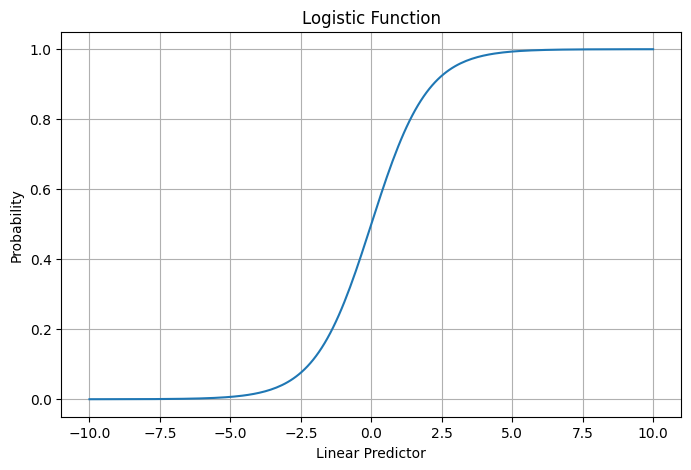

In [3]:
x = np.linspace(-10, 10, 200)

probability = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8, 5))
plt.plot(x, probability)

plt.xlabel("Linear Predictor")
plt.ylabel("Probability")
plt.title("Logistic Function")

plt.grid(True)
plt.show()

## 7. Log Link Function

Poisson Regression commonly uses the log link function.

Let:

$$
\mu = E[Y|X]
$$

The log link is:

$$
g(\mu) = \ln(\mu)
$$

Therefore:

$$
\ln(\mu)
=
\beta_0 + \beta_1x_1 + \cdots + \beta_px_p
$$

Applying the inverse link:

$$
\mu =
e^\eta
$$

Therefore:

$$
\mu =
\exp(
\beta_0 + \beta_1x_1 + \cdots + \beta_px_p
)
$$

Because the exponential function is always positive:

$$
\mu > 0
$$

This makes the log link useful for modeling count data.

## 8. Common GLMs

Some important GLMs are:

### Linear Regression

Response distribution:

$$
Y \sim Normal(\mu,\sigma^2)
$$

Link:

$$
g(\mu)=\mu
$$

---

### Logistic Regression

Response distribution:

$$
Y \sim Binomial(n,p)
$$

Link:

$$
g(p)=\ln\left(\frac{p}{1-p}\right)
$$

---

### Poisson Regression

Response distribution:

$$
Y \sim Poisson(\mu)
$$

Link:

$$
g(\mu)=\ln(\mu)
$$

These models share the same general GLM framework but differ in their response distribution and link function.

## 9. GLM vs Linear Regression

Linear Regression assumes:

$$
Y|X \sim Normal(\mu,\sigma^2)
$$

and:

$$
\mu = X\beta
$$

This means the expected target is directly modeled by a linear combination of the features.

The main limitation is that the target must be suitable for this continuous Gaussian framework.

GLMs generalize this idea.

Instead of requiring:

$$
\mu = X\beta
$$

we use:

$$
g(\mu)=X\beta
$$

This allows the expected response to be transformed appropriately.

## 10. Logistic Regression as a GLM

Logistic Regression is one of the most important examples of a GLM.

The model is:

$$
\text{logit}(p)=X\beta
$$

where:

$$
p=P(Y=1|X)
$$

Therefore:

$$
p =
\frac{1}{1+e^{-X\beta}}
$$

### GLM components

| Component | Logistic Regression |
|---|---|
| Response distribution | Binomial |
| Mean | $p$ |
| Link | Logit |
| Linear predictor | $X\beta$ |

We already studied Logistic Regression in the previous notebook.

Now we can understand it as part of the larger GLM framework.

## 11. Poisson Regression

Poisson Regression is designed for modeling count data.

Examples:

- Number of website visits
- Number of insurance claims
- Number of customer purchases
- Number of accidents
- Number of calls received
- Number of events occurring during a fixed period

The response variable is:

$$
Y \in \{0,1,2,3,\ldots\}
$$

We assume:

$$
Y \sim Poisson(\mu)
$$

The probability mass function is:

$$
P(Y=y)
=
\frac{e^{-\mu}\mu^y}{y!}
$$

where:

$$
\mu > 0
$$

Poisson Regression models:

$$
\ln(\mu)=X\beta
$$

Therefore:

$$
\mu=e^{X\beta}
$$

## 12. Creating a Count Dataset

Let's create a simple dataset representing the number of website visits based on advertising expenditure.

The target variable will be:

**Number of visits**

Since visits are count values, Poisson Regression is a suitable model.

In [4]:
np.random.seed(42)

n_samples = 200

advertising = np.random.uniform(1, 10, n_samples)

true_mean = np.exp(
    1.0 + 0.25 * advertising
)

visits = np.random.poisson(true_mean)

data = pd.DataFrame({
    "Advertising": advertising,
    "Visits": visits
})

data.head()

,Advertising,Visits
0,4.370861,5
1,9.556429,21
2,7.587945,19
3,6.387926,15
4,2.404168,8


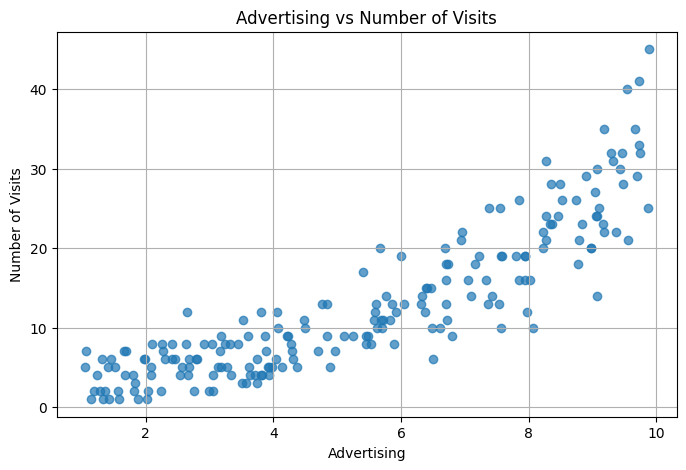

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["Advertising"],
    data["Visits"],
    alpha=0.7
)

plt.xlabel("Advertising")
plt.ylabel("Number of Visits")
plt.title("Advertising vs Number of Visits")

plt.grid(True)
plt.show()

## 13. Train-Test Split

We separate the features and target variable.

Feature:

$$
X = Advertising
$$

Target:

$$
y = Visits
$$

Then we split the dataset into training and testing sets.

In [6]:
X = data[["Advertising"]]
y = data["Visits"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


## 14. Training a Poisson Regression Model

Scikit-learn provides `PoissonRegressor` for Poisson Regression.

The model estimates:

$$
\ln(\mu)
=
\beta_0+\beta_1x
$$

and therefore:

$$
\mu
=
e^{\beta_0+\beta_1x}
$$

In [7]:
poisson_model = PoissonRegressor(
    alpha=0,
    max_iter=1000
)

poisson_model.fit(
    X_train,
    y_train
)

print("Intercept:", poisson_model.intercept_)
print("Coefficient:", poisson_model.coef_[0])

Intercept: 0.9637368586848633
Coefficient: 0.2532920443454868


## 15. Making Predictions

The model predicts the expected number of visits.

Because Poisson Regression uses the log link:

$$
\hat{\mu}
=
\exp(X\hat{\beta})
$$

the predicted mean is always positive.

In [8]:
y_pred = poisson_model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,8,10.409297
1,12,5.130089
2,15,13.490765
3,5,5.805201
4,7,3.431087
5,23,24.621873
6,45,32.032929
7,14,15.825521
8,9,14.699054
9,22,15.292057


## 16. Evaluating Poisson Regression

For count data, the **Poisson deviance** is an appropriate evaluation metric.

The mean Poisson deviance is:

$$
D =
\frac{1}{n}
\sum_{i=1}^{n}
2
\left[
y_i\ln\left(\frac{y_i}{\hat{\mu}_i}\right)
-
(y_i-\hat{\mu}_i)
\right]
$$

with the convention that:

$$
0\ln(0/\hat{\mu})=0
$$

Lower Poisson deviance indicates better predictive performance.

In [9]:
poisson_deviance = mean_poisson_deviance(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Mean Poisson Deviance:", poisson_deviance)
print("Mean Absolute Error:", mae)

Mean Poisson Deviance: 1.1274570369952408
Mean Absolute Error: 3.026298328533835


c:\Users\soumy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PoissonRegressor was fitted with feature names
  warnings.warn(


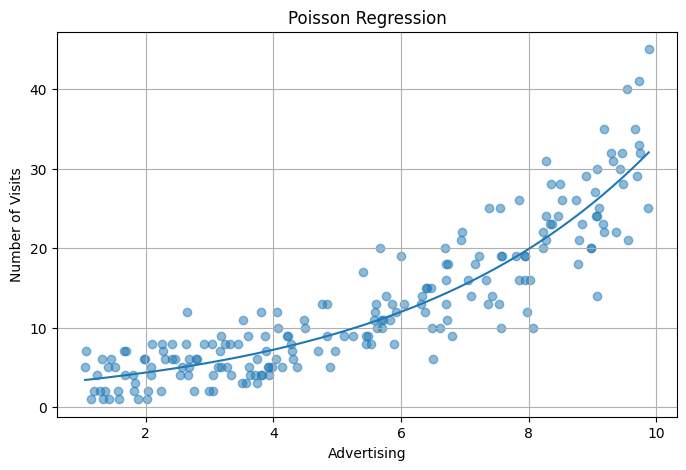

In [10]:
x_range = np.linspace(
    X["Advertising"].min(),
    X["Advertising"].max(),
    200
).reshape(-1, 1)

prediction = poisson_model.predict(x_range)

plt.figure(figsize=(8, 5))

plt.scatter(
    X["Advertising"],
    y,
    alpha=0.5
)

plt.plot(
    x_range,
    prediction
)

plt.xlabel("Advertising")
plt.ylabel("Number of Visits")
plt.title("Poisson Regression")

plt.grid(True)
plt.show()

## 17. Interpreting Poisson Regression Coefficients

Suppose the model is:

$$
\ln(\mu)=\beta_0+\beta_1x
$$

Then:

$$
\mu=e^{\beta_0+\beta_1x}
$$

If $x$ increases by one unit:

$$
\mu_{new}
=
e^{\beta_0+\beta_1(x+1)}
$$

Therefore:

$$
\frac{\mu_{new}}{\mu}
=
e^{\beta_1}
$$

So $e^{\beta_1}$ is the multiplicative change in the expected count for a one-unit increase in $x$.

For example, if:

$$
\beta_1=0.2
$$

then:

$$
e^{0.2}\approx1.22
$$

This means the expected count is multiplied by approximately 1.22, corresponding to about a **22% increase** for a one-unit increase in the feature.

In [11]:
coefficient = poisson_model.coef_[0]

multiplicative_effect = np.exp(coefficient)

print("Coefficient:", coefficient)
print("Multiplicative Effect:", multiplicative_effect)
print(
    "Percentage Change:",
    (multiplicative_effect - 1) * 100,
    "%"
)

Coefficient: 0.2532920443454868
Multiplicative Effect: 1.2882594507903415
Percentage Change: 28.825945079034156 %


## 18. Comparing Linear, Logistic and Poisson Regression

The three models can be understood using the GLM framework.

| Model | Target | Distribution | Link |
|---|---|---|---|
| Linear Regression | Continuous | Normal | Identity |
| Logistic Regression | Binary | Binomial | Logit |
| Poisson Regression | Count | Poisson | Log |

### Linear Regression

$$
\mu=X\beta
$$

### Logistic Regression

$$
\ln\left(\frac{p}{1-p}\right)=X\beta
$$

### Poisson Regression

$$
\ln(\mu)=X\beta
$$

The important idea is:

> The linear predictor $X\beta$ remains central, while the distribution and link function change according to the problem.

## 19. A Simple GLM Decision Guide

When choosing a GLM, first identify the type of target variable.

### Continuous target

Example:

- House price
- Salary
- Temperature

Use:

**Linear Regression**

---

### Binary target

Example:

- Yes / No
- Purchased / Not Purchased
- Disease / No Disease

Use:

**Logistic Regression**

---

### Count target

Example:

- Number of visits
- Number of claims
- Number of purchases

Use:

**Poisson Regression**

The target distribution should therefore be considered before choosing the model.

## 20. Advantages of Generalized Linear Models

GLMs have several important advantages.

### 1. Flexible target distributions

GLMs can model different types of response variables.

### 2. Interpretable coefficients

The coefficients often have meaningful interpretations.

### 3. Unified framework

Linear Regression, Logistic Regression and Poisson Regression can all be understood using the same GLM framework.

### 4. Appropriate predictions

The link function can constrain predictions to a meaningful range.

For example:

- Logistic Regression → probabilities between 0 and 1
- Poisson Regression → positive expected counts

### 5. Statistical foundation

GLMs are based on probability distributions and likelihood-based estimation, providing a strong statistical foundation.

## 21. Limitations of GLMs

GLMs are powerful, but they also have limitations.

### 1. Distribution assumptions

The chosen response distribution should be appropriate for the data.

### 2. Relationship assumptions

The transformed mean response is assumed to have a linear relationship with the predictors:

$$
g(\mu)=X\beta
$$

### 3. Outliers

Extreme observations can strongly influence model estimates.

### 4. Overdispersion

Poisson Regression assumes:

$$
E[Y]=Var(Y)
$$

Real-world count data may have:

$$
Var(Y)>E[Y]
$$

This is known as **overdispersion**.

In such cases, alternatives such as Negative Binomial Regression may be more appropriate.

## 22. Important Mathematical Summary

The general GLM equation is:

$$
g(\mu)=X\beta
$$

where:

$$
\mu=E[Y|X]
$$

and:

$$
X\beta
=
\beta_0+\beta_1x_1+\cdots+\beta_px_p
$$

The inverse link gives:

$$
\mu=g^{-1}(X\beta)
$$

### Linear Regression

$$
g(\mu)=\mu
$$

Therefore:

$$
\mu=X\beta
$$

### Logistic Regression

$$
g(\mu)
=
\ln\left(\frac{\mu}{1-\mu}\right)
$$

Therefore:

$$
\mu=
\frac{1}{1+e^{-X\beta}}
$$

### Poisson Regression

$$
g(\mu)=\ln(\mu)
$$

Therefore:

$$
\mu=e^{X\beta}
$$

# 23. Final Summary

Generalized Linear Models extend Linear Regression to a wider range of response variables.

The three fundamental components of a GLM are:

1. **Random component**
   - Specifies the probability distribution of the response.

2. **Systematic component**
   - The linear predictor:

   $$
   \eta=X\beta
   $$

3. **Link function**
   - Connects the expected response to the linear predictor:

   $$
   g(\mu)=X\beta
   $$

Important examples include:

| Model | Distribution | Link |
|---|---|---|
| Linear Regression | Normal | Identity |
| Logistic Regression | Binomial | Logit |
| Poisson Regression | Poisson | Log |

The central idea to remember is:

$$
\boxed{g(E[Y|X])=X\beta}
$$

This equation provides a unified way to understand many important regression models.